In [1]:
import numpy as np
import bacco
import matplotlib.pyplot as plt

In [2]:
import os
os.chdir("/cosmos_storage/home/fgmaion/MTNG-resims/src")
import utils

%matplotlib inline
%load_ext autoreload
%autoreload 2

In [18]:
def pars(i, mstar):

    arr = np.vstack( ( mstar, np.ones(len(mstar)) * wind_en[i],\
                        np.ones(len(mstar)) * wind_vel[i],\
                        np.ones(len(mstar)) * rho_rec[i],\
                        np.ones(len(mstar)) * sf_ts[i],\
                        np.ones(len(mstar)) * ef_kin[i],\
                        np.ones(len(mstar)) * ef_high[i],\
                        np.ones(len(mstar)) * f_re[i])).T

    return arr

In [21]:
wind_en_or      = []
wind_vel_or     = []
rho_rec_or      = []
sf_ts_or        = []
ef_kin_or       = []
ef_high_or      = []
f_re_or         = []

for i in range(31):
    if i<30:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro_{:d}.txt".format(i)
    else:
        filename = "/cosmos_storage/simulations/TNG_Family/MN5_resims/param_LH/param_MTNG-hydro.txt"

    with open(filename, 'r') as f:
        for line in f.readlines():
            if len(line.split())!=0:
                if line.split()[0] == 'WindEnergyIn1e51erg':
                    wind_en_or.append(float(line.split()[1]))
                if line.split()[0] == 'VariableWindVelFactor':
                    wind_vel_or.append(float(line.split()[1]))
                if line.split()[0] == 'WindFreeTravelDensFac':
                    rho_rec_or.append(float(line.split()[1]))
                if line.split()[0] == 'MaxSfrTimescale':
                    sf_ts_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackFactor':
                    ef_kin_or.append(float(line.split()[1]))
                if line.split()[0] == 'BlackHoleFeedbackFactor':
                    ef_high_or.append(float(line.split()[1]))
                if line.split()[0] == 'RadioFeedbackReiorientationFactor':
                    f_re_or.append(float(line.split()[1]))

rho_rec_or = np.log10(rho_rec_or)
ef_kin_or = np.log10(ef_kin_or)
        
wind_en   = (np.asarray(wind_en_or) - np.mean(wind_en_or)) / np.std(wind_en_or)
wind_vel  = (np.asarray(wind_vel_or) - np.mean(wind_vel_or)) / np.std(wind_vel_or)
rho_rec   = (np.asarray(rho_rec_or) - np.mean(rho_rec_or)) / np.std(rho_rec_or)
sf_ts     = (np.asarray(sf_ts_or) - np.mean(sf_ts_or)) / np.std(sf_ts_or)
ef_kin    = (np.asarray(ef_kin_or) - np.mean(ef_kin_or)) / np.std(ef_kin_or)
ef_high   = (np.asarray(ef_high_or) - np.mean(ef_high_or)) / np.std(ef_high_or)
f_re      = (np.asarray(f_re_or) - np.mean(f_re_or)) / np.std(f_re_or)

In [3]:
name_list = ['LH_{:d}'.format(i) for i in range(30)] + ['fiducial']

sigma8 = 0.8159 #CHECK ME
ns     = 0.9667 #CHECK ME
tau    = 0.0965 #CHECK ME

snap = 264
zoom = {}

for i in range(len(name_list)):
    if i<30:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/LH_{:d}/hydro_output/".format(i)
    else:
        base = "/cosmos_storage/simulations/TNG_Family/MN5_resims/fiducial/hydro_output/"
    zoom[name_list[i]] = bacco.Simulation(basedir=base, halo_file="groups_{:03d}/fof_subhalo_tab_{:03d}".format(snap,snap), sim_format='TNG500', fixedPk=True, use_orphans=False,\
                            tau=tau, ns=ns, sigma8=sigma8, dm_file="snapdir_{:03d}/snapshot_{:03d}".format(snap,snap), use_ids=True, numpart=4320)


2026-03-16 20:03:13,740 bacco.sims : Initialising simulation Default
2026-03-16 20:03:13,742 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264
2026-03-16 20:03:13,812 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_0/hydro_output/snapdir_264/snapshot_264


2026-03-16 20:03:14,268 bacco.sims : ...done in 0.0976 s
2026-03-16 20:03:14,269 bacco.sims : Initialising simulation Default
2026-03-16 20:03:14,269 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264
2026-03-16 20:03:14,343 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_1/hydro_output/snapdir_264/snapshot_264
2026-03-16 20:03:14,774 bacco.sims : ...done in 0.0914 s
2026-03-16 20:03:14,774 bacco.sims : Initialising simulation Default
2026-03-16 20:03:14,775 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/snapdir_264/snapshot_264
2026-03-16 20:03:14,814 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MN5_resims/LH_2/hydro_output/snapdir_264/snapshot_264
2026-03-16 20:03:14,868 bacco.sims : ...done in 0.0587 s
2026-03-16 20:03:14,868 bacco.sims : Initialising simulation Default
2026-03-16 20:03:14,869 bacco.sims : try /cosmos_storage/simulations/TNG_Famil

In [4]:
# Load the Halo Selection
with open("/cosmos_storage/simulations/TNG_Family/MN5_resims/resims_info/hydro_halo_sel_1pmbin.txt") as f:
    final_sel = []

    for line in f.readlines():
        final_sel.append(int(line.split()[0]))

final_sel = np.array(final_sel)

# Perform the cross-match with MTNG halos
xmatch = {}

for i in range(len(name_list)):
    xmatch[name_list[i]] = utils.cross_match(zoom[name_list[i]], snap=264, name=name_list[i])

# Load MTNG and get the fraction of halos to do the upweighting
mtng = bacco.utils.load_MTNG(adr="/cosmos_storage/simulations/TNG_Family/MTNG/", snap=264)

m200b = np.log10(1e10 * mtng.fof['halo_m200b'])

mbins = np.concatenate(
    (np.arange(11, 11.5, 0.0025),
    np.arange(11.5, 12.5, 0.005),
    np.arange(12.5, 13.5, 0.025),
    np.arange(13.5, 15.01, 0.125))
)

h_frac = np.zeros(len(final_sel))
for m in range(len(mbins)-1):
    h_frac[m] = np.where(( m200b[final_sel]>=mbins[m]) & ( m200b[final_sel]<mbins[m+1]))[0].shape[0] / \
             np.where(( m200b>=mbins[m]) & ( m200b<mbins[m+1]))[0].shape[0]

zoom_split = {}
zoom_sel = {}
for i in range(len(name_list)):
    zoom_split[name_list[i]] = utils.split_halos(zoom[name_list[i]])

    zoom_sel[name_list[i]] = {}

    zoom_sel[name_list[i]]['sel'] = xmatch[name_list[i]]['ind'][:,np.newaxis,np.newaxis]
    zoom_sel[name_list[i]]['h_frac'] = h_frac[np.newaxis, :]

2026-03-16 20:03:23,301 bacco.sims : Initialising simulation Default
2026-03-16 20:03:23,301 bacco.sims : try /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-03-16 20:03:23,303 bacco.sims : Loading /cosmos_storage/simulations/TNG_Family/MTNG/groups_264/fof_subhalo_tab_264
2026-03-16 20:03:23,331 bacco.sims : ...done in 0.00518 s
2026-03-16 20:03:23,337 bacco.sims : Reading 98233510 items for Group_M_Mean200


/tmp/ipykernel_386577/87356854.py:19: RuntimeWarning: divide by zero encountered in log10
  m200b = np.log10(1e10 * mtng.fof['halo_m200b'])


In [5]:
bh_mf = {}

for i in range(len(name_list)):
    bh_mf[name_list[i]] = zoom_split[name_list[i]].bh_mf(sel_mask=zoom_sel[name_list[i]], nbins=20)

2026-03-16 20:06:26,272 bacco.sims : Reading 142791 items for halo_firstsub


2026-03-16 20:06:26,869 bacco.sims : Reading 142791 items for GroupNsubs
2026-03-16 20:06:26,891 bacco.sims : Reading 76572 items for SubhaloBHMass
2026-03-16 20:06:27,440 bacco.sims : Reading 143520 items for halo_firstsub
2026-03-16 20:06:28,086 bacco.sims : Reading 143520 items for GroupNsubs
2026-03-16 20:06:28,104 bacco.sims : Reading 74995 items for SubhaloBHMass
2026-03-16 20:06:28,663 bacco.sims : Reading 146601 items for halo_firstsub
2026-03-16 20:06:29,302 bacco.sims : Reading 146601 items for GroupNsubs
2026-03-16 20:06:29,331 bacco.sims : Reading 76208 items for SubhaloBHMass
2026-03-16 20:06:29,732 bacco.sims : Reading 141432 items for halo_firstsub
2026-03-16 20:06:30,367 bacco.sims : Reading 141432 items for GroupNsubs
2026-03-16 20:06:30,397 bacco.sims : Reading 75118 items for SubhaloBHMass
2026-03-16 20:06:30,975 bacco.sims : Reading 145271 items for halo_firstsub
2026-03-16 20:06:31,636 bacco.sims : Reading 145271 items for GroupNsubs
2026-03-16 20:06:31,661 bacco.s

In [6]:
mtng_bhmf = utils.get_mtng_bhmf(mtng, nbins=20)

2026-03-16 20:07:00,773 bacco.sims : Reading 90246895 items for SubhaloBHMass


In [7]:
# Load BHMF
Nbins_bhmf = 10

zoom_bhmf = {}
for i in range(len(name_list)):
    zoom_bhmf[name_list[i]] = np.load("/cosmos_storage/home/fgmaion/MTNG-resims/results/bhmf/bhmf_{}_Nbins{:d}.npy".format(name_list[i], Nbins_bhmf), allow_pickle=True)[0]


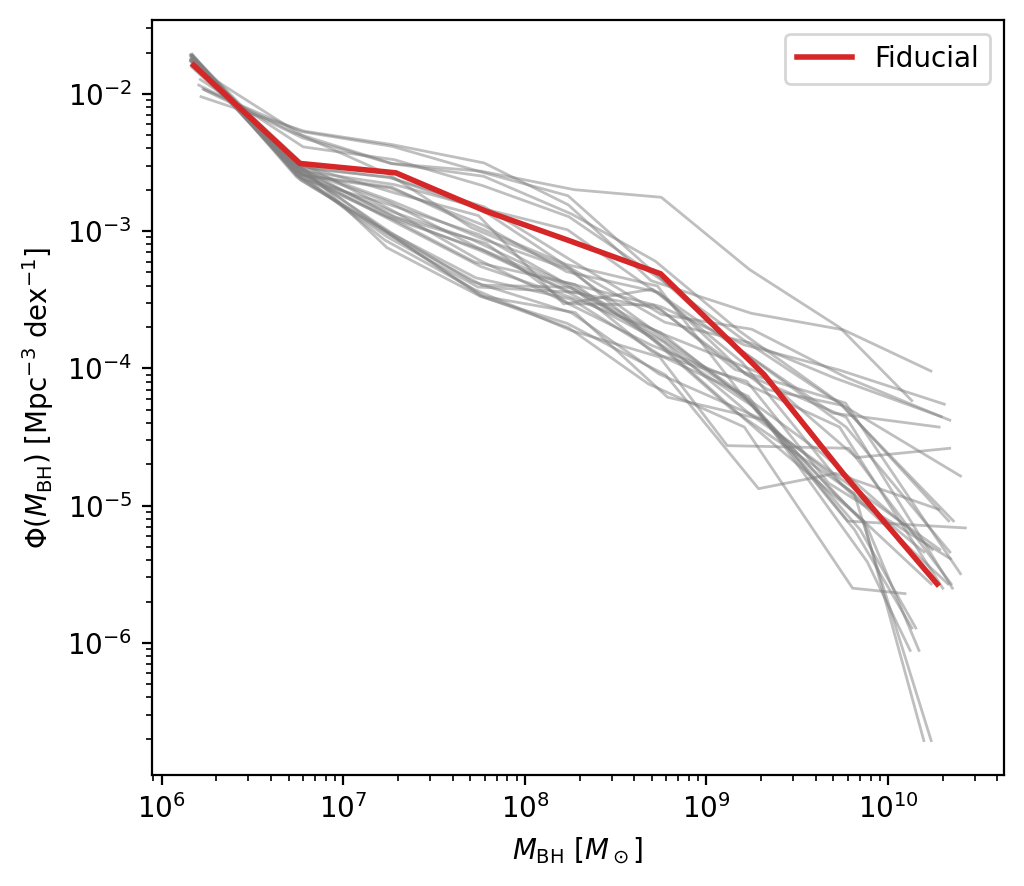

In [8]:
fig, ax = plt.subplots(dpi=200, figsize=(5.5,5))

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_ylabel(r"$\Phi(M_{\rm BH})$ [Mpc$^{-3}$ dex$^{-1}$]")
ax.set_xlabel(r"$M_{\rm BH}$ [$M_\odot$]")

for i in range(len(name_list)-1):
    ax.plot(zoom_bhmf[name_list[i]]['mbh'], zoom_bhmf[name_list[i]]['bhmf'], color='gray', alpha=0.5, lw=1)

ax.plot(zoom_bhmf['fiducial']['mbh'], zoom_bhmf['fiducial']['bhmf'], label='Fiducial', color='C3', lw=2)
# ax.plot(mtng_bhmf['mbh'], mtng_bhmf['bhmf'], label='MTNG', color='k', lw=2)

ax.legend()


In [13]:
import sys
sys.path.append("/cosmos_storage/home/fgmaion/MTNG-resims/scripts")
from GP_models import SMF_Model, fgas_Model
import torch
import gpytorch

In [26]:
model_bhmf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_model_bhmf.pth")
likelihood_bhmf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_likelihood_bhmf.pth")

model_bhmf.eval()
likelihood_bhmf.eval()

/tmp/ipykernel_386577/2204472259.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_bhmf = torch.load("/cosmos_storage/home/fgmaion/MTNG-resims/gp_train_results/full_

GaussianLikelihood(
  (noise_covar): HomoskedasticNoise(
    (raw_noise_constraint): GreaterThan(1.000E-02)
  )
)

In [27]:
# Define the training set
train_sel = np.arange(31)

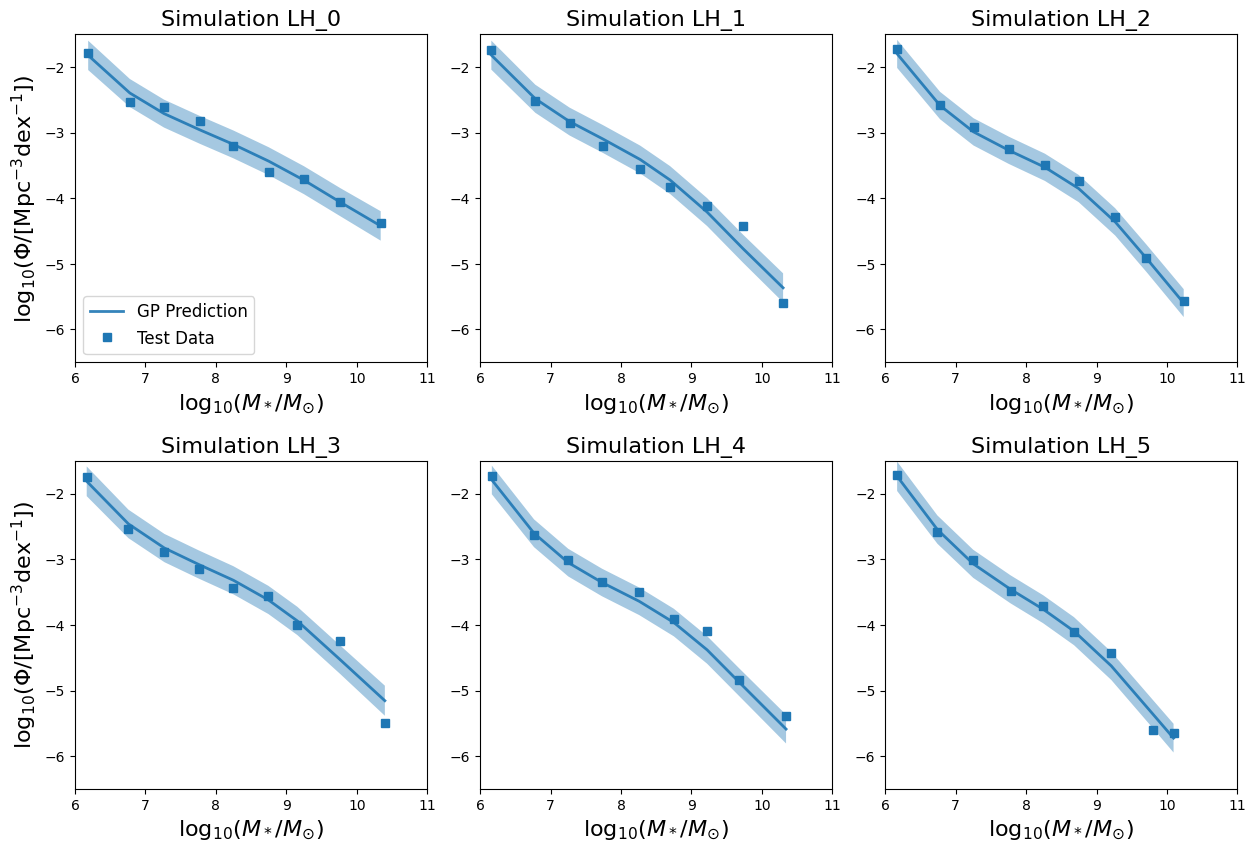

In [36]:
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    # Initialize plot
    f, ax = plt.subplots(2, 3, figsize=(15, 10), dpi=100)
    plt.subplots_adjust(wspace=0.15, hspace=0.3)

    for i in range(2):
        for j in range(3):
            test_x = torch.asarray(pars(train_sel[3*i+j], np.log10(zoom_bhmf[name_list[train_sel[3*i+j]]]['mbh'])), dtype=torch.float)
            observed_pred = likelihood_bhmf(model_bhmf(torch.asarray(test_x, dtype=torch.float)))
        
            ax[i,j].set_xlim(6,11)
            ax[i,j].set_ylim(-6.5, -1.5)

            ax[i,j].set_title('Simulation {:s}'.format(name_list[train_sel[3*i+j]]), fontsize=16)

            if j==0:
                ax[i,j].set_ylabel('$\log_{10}(\Phi/[\mathrm{Mpc}^{-3}\mathrm{dex}^{-1}])$', fontsize=16)
            
            ax[i,j].set_xlabel('$\log_{10}(M_*/M_{\odot})$', fontsize=16)

            # Get upper and lower confidence bounds
            lower, upper = observed_pred.confidence_region()

            # Shade between the lower and upper confidence bounds
            ax[i,j].fill_between(test_x[:,0].numpy(), observed_pred.mean.numpy()-observed_pred.stddev.numpy(), observed_pred.mean.numpy()+observed_pred.stddev.numpy(), color='C0', alpha=0.4, edgecolor=None)
            ax[i,j].plot(test_x[:,0], observed_pred.mean.numpy(), 'C0', lw=2, label="GP Prediction", alpha=0.9)

            # Plot test data as blue squares
            ax[i,j].plot(np.log10(zoom_bhmf[name_list[train_sel[3*i+j]]]['mbh']), np.log10(zoom_bhmf[name_list[train_sel[3*i+j]]]['bhmf']), 's', color="C0", label="Test Data")

ax[0,0].legend(loc='lower left', fontsize=12)

plt.savefig("/cosmos_storage/home/fgmaion/MTNG-resims/results/testing_plots/bhmf_test.pdf", bbox_inches='tight')